In [15]:
import pandas as pd
import numpy as np
import sys,os
from tqdm import tqdm
import sys, os
import compass
print("Using COMPASS version:", compass.__version__)

from compass.utils import plot_embed_with_label,plot_performance, score2
from compass.tokenizer import CANCER_CODE, CONCEPT
from compass import PreTrainer, FineTuner, loadcompass #, get_minmal_epoch
from compass.tokenizer import CANCER_CODE, CONCEPT

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from copy import deepcopy

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression

%matplotlib inline

def onehot(S):
    assert type(S) == pd.Series, 'Input type should be pd.Series'
    dfd = pd.get_dummies(S, dummy_na=True)
    nanidx = dfd[dfd[np.nan].astype(bool)].index
    dfd.loc[nanidx, :] = np.nan
    dfd = dfd.drop(columns=[np.nan])*1.
    cols = dfd.sum().sort_values(ascending=False).index.tolist()
    dfd = dfd[cols]
    return dfd

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

def train_lgr_with_gridsearch(
    train_X, train_y,
    scoring='roc_auc', cv=10, n_jobs=-1, random_state=42):
    """
    1) GridSearchCV find best parameters
    2) best parameters for refit(train_X, train_y) 
    3) return: best_estimator_, best_params_, best_cv_score, final_model
    """
    # Build a pipeline: standardize -> logistic regression
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty="l2", solver="lbfgs", class_weight="balanced",
            max_iter=1000, random_state=random_state
        ))
    ])

    # Param grid (only search C on the classifier step)
    param_grid = {
        "clf__C": np.logspace(-3, 2, 100)  # 
    }

    # Stratified CV for classification
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

    gcv = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=skf,
        n_jobs=n_jobs,
        refit=True,          # refit pipeline on the whole train set using best params
        verbose=0
    )
    gcv.fit(train_X, train_y)

    best_params = gcv.best_params_
    best_cv_score = gcv.best_score_
    # best_estimator = gcv.best_estimator_   # already refit on full train set

    # Optionally, extract best C for reporting
    best_C = best_params["clf__C"]

    print(f"[GridSearch] best_C={best_C:.3g}, best_{scoring}={best_cv_score:.4f}")

    # best_estimator is the final model trained on the full training data
    return gcv

Using COMPASS version: 2.0.5


In [16]:
data_path = './data/ITRP/'
df_label = pd.read_pickle(os.path.join(data_path, 'ITRP.PATIENT.TABLE'))
df_tpm = pd.read_pickle(os.path.join(data_path, 'ITRP.TPM.TABLE'))
df_tpm.shape, df_label.shape

dfcx = df_label.cancer_type.map(CANCER_CODE).to_frame('cancer_code').join(df_tpm)

In [17]:
s = df_label.cohort.value_counts()
large_medium_cohorts = s.index.tolist() #s[s  > 30].index.tolist() #
#[s.index != 'Kim']
#df_label = df_label[df_label.cohort.isin(large_cohorts)]
cohort_list = df_label.cohort.unique().tolist()

In [18]:
cohort_map = s.index + '(n=' + s.astype(str) + ')'

In [19]:
y = onehot(df_label.response_label)

In [20]:
def leave_one_cohort_out(cohorts):
    # Create a list of lists, each missing one element from the original list
    return [(cohorts[i], cohorts[:i] + cohorts[i+1:]) for i in range(len(cohorts))]
train_test_cohorts = leave_one_cohort_out(cohort_list)

## ssGSEA-Avg-LGR

In [21]:
X1 = pd.read_csv('./data/GSEA/ITRP_avg_concept_43.csv', index_col=0)
X3 = pd.read_csv('./data/GSEA/ITRP_ssGSEA_concept_43.csv', index_col=0)

X5 = pd.read_csv('./data/GSEA/ITRP_avg_signature_132.csv', index_col=0)
X7 = pd.read_csv('./data/GSEA/ITRP_ssGSEA_signature_132.csv', index_col=0)

Modes = ['Geometric mean from Gene TPM', 
         'ssGSEA from Gene TPM', 
        ]
Xs1 = [X1, X3]
Xs2 = [X5, X7]
levels = ['concepts', 'signatures']

final_performance = []

for level, Xs in zip(levels, [Xs1, Xs2]):
    for X, mode in zip(Xs, Modes):
        
        res = []
        for test_cohort, train_cohorts in train_test_cohorts:
    
            train_cohort_name = 'Leave_%s_out' % test_cohort
            ## Get data for this cohort
            cohort_idx = df_label[df_label['cohort'].isin(train_cohorts)].index
            cohort_X = X.loc[cohort_idx]
            cohort_y = y.loc[cohort_idx]
    
            train_X = cohort_X 
            train_y = cohort_y['R'].values
    
            test_cohort_idx = df_label[df_label['cohort'] == test_cohort].index
            test_cohort_X = X.loc[test_cohort_idx]

            test_cohort_y = y.loc[test_cohort_idx]['R']
    
            gcv = train_lgr_with_gridsearch(train_X, train_y)
            test_pred_prob = gcv.best_estimator_.predict_proba(test_cohort_X)
            dfp = pd.DataFrame(test_pred_prob, index =test_cohort_y.index )
    
            dfp['train_cohort'] = train_cohort_name
            dfp['test_cohort'] = test_cohort    
            dfp['best_C'] = gcv.best_params_["clf__C"]
            dfp['mode'] = mode
            
            dfp = dfp.join(test_cohort_y)
            y_true, y_prob, y_pred = dfp['R'], dfp[1], dfp[[0, 1]].idxmax(axis=1)
            
            res.append(dfp)
    
        dfs = pd.concat(res)
        dfp = dfs.groupby(['train_cohort', 'test_cohort']).apply(lambda x:score2(x['R'], x[1], x[[0, 1]].idxmax(axis=1)))
        mode_map = dfs.groupby('train_cohort')['mode'].unique().apply(lambda x:x[0])
        c_map = dfs.groupby('train_cohort')['best_C'].unique().apply(lambda x:x[0])
        
        #roc, prc, f1, acc, mcc
        dfp = dfp.apply(pd.Series)
        dfp.columns = ['ROC', 'PRC', 'F1', 'ACC', 'MCC']
        dfp = dfp.reset_index()
        dfp['mode'] = dfp.train_cohort.map(mode_map)
        dfp['best_C'] = dfp.train_cohort.map(c_map)
        dfp['level'] = level
        final_performance.append(dfp)
dfp1 = pd.concat(final_performance)

[GridSearch] best_C=0.0413, best_roc_auc=0.6664
[GridSearch] best_C=0.187, best_roc_auc=0.6744
[GridSearch] best_C=0.236, best_roc_auc=0.6844
[GridSearch] best_C=0.083, best_roc_auc=0.6940
[GridSearch] best_C=0.0183, best_roc_auc=0.6811
[GridSearch] best_C=0.187, best_roc_auc=0.6696
[GridSearch] best_C=0.132, best_roc_auc=0.6760
[GridSearch] best_C=0.534, best_roc_auc=0.6895
[GridSearch] best_C=0.0586, best_roc_auc=0.6886
[GridSearch] best_C=0.0933, best_roc_auc=0.6900
[GridSearch] best_C=0.0464, best_roc_auc=0.6629
[GridSearch] best_C=0.0658, best_roc_auc=0.6847
[GridSearch] best_C=0.0413, best_roc_auc=0.6943
[GridSearch] best_C=0.0658, best_roc_auc=0.6822
[GridSearch] best_C=0.148, best_roc_auc=0.6889
[GridSearch] best_C=0.0292, best_roc_auc=0.6652
[GridSearch] best_C=0.0292, best_roc_auc=0.6745
[GridSearch] best_C=0.0368, best_roc_auc=0.6751
[GridSearch] best_C=0.132, best_roc_auc=0.6863
[GridSearch] best_C=0.105, best_roc_auc=0.6939
[GridSearch] best_C=0.0231, best_roc_auc=0.6803
[

## COMPASS-LGR

In [22]:
seed = 42 # use 24, 42, 64
mode = 'COMPASS'
Modes.append(mode)

levels = ['concepts', 'signatures']

final_performance = []

for level in levels:

    res = []
    for test_cohort, train_cohorts in train_test_cohorts:
    
        pth = f'./compass_run/FT_v100/LOCO_PFT_{seed}/leave_{test_cohort}_out.pt'
        compass_model = loadcompass(pth, map_location = 'cuda:0')
        dfcx1 = dfcx[['cancer_code']].join(dfcx[compass_model.feature_name])
        dfe, dfg, dfc = compass_model.extract(dfcx1,  batch_size= 128, with_gene_level = True)

        if level == 'concepts':
            X = dfc
            X = X[X.columns[1:]]
        else:
            X = dfg
            X = X[X.columns[1:]]
    
        train_cohort_name = 'Leave_%s_out' % test_cohort
        ## Get data for this cohort
        cohort_idx = df_label[df_label['cohort'].isin(train_cohorts)].index
        cohort_X = X.loc[cohort_idx]
        cohort_y = y.loc[cohort_idx]

        train_X = cohort_X 
        train_y = cohort_y['R'].values

        test_cohort_idx = df_label[df_label['cohort'] == test_cohort].index
        test_cohort_X = X.loc[test_cohort_idx]

        test_cohort_y = y.loc[test_cohort_idx]['R']

        gcv = train_lgr_with_gridsearch(train_X, train_y)
        test_pred_prob = gcv.best_estimator_.predict_proba(test_cohort_X)
        dfp = pd.DataFrame(test_pred_prob, index =test_cohort_y.index )

        dfp['train_cohort'] = train_cohort_name
        dfp['test_cohort'] = test_cohort    
        dfp['best_C'] = gcv.best_params_["clf__C"]
        dfp['mode'] = mode
            
        dfp = dfp.join(test_cohort_y)
        y_true, y_prob, y_pred = dfp['R'], dfp[1], dfp[[0, 1]].idxmax(axis=1)
        
        res.append(dfp)

    dfs = pd.concat(res)
    dfp = dfs.groupby(['train_cohort', 'test_cohort']).apply(lambda x:score2(x['R'], x[1], x[[0, 1]].idxmax(axis=1)))
    mode_map = dfs.groupby('train_cohort')['mode'].unique().apply(lambda x:x[0])
    c_map = dfs.groupby('train_cohort')['best_C'].unique().apply(lambda x:x[0])
    
    #roc, prc, f1, acc, mcc
    dfp = dfp.apply(pd.Series)
    dfp.columns = ['ROC', 'PRC', 'F1', 'ACC', 'MCC']
    dfp = dfp.reset_index()
    dfp['mode'] = dfp.train_cohort.map(mode_map)
    dfp['best_C'] = dfp.train_cohort.map(c_map)
    dfp['level'] = level
    final_performance.append(dfp)
dfp2 = pd.concat(final_performance)

100%|#####################################################################################| 9/9 [00:00<00:00, 17.67it/s]


[GridSearch] best_C=0.335, best_roc_auc=0.9618


100%|#####################################################################################| 9/9 [00:00<00:00, 17.98it/s]


[GridSearch] best_C=0.475, best_roc_auc=0.9755


100%|#####################################################################################| 9/9 [00:00<00:00, 17.82it/s]


...

[GridSearch] best_C=0.0586, best_roc_auc=0.9601


100%|#####################################################################################| 9/9 [00:00<00:00, 17.72it/s]


[GridSearch] best_C=0.0658, best_roc_auc=0.9628


100%|#####################################################################################| 9/9 [00:00<00:00, 17.68it/s]


[GridSearch] best_C=0.105, best_roc_auc=0.9652


In [23]:
dfp = dfp1._append(dfp2)
dfpf = dfp[dfp.test_cohort.isin(large_medium_cohorts)]

In [24]:
roc = dfpf.groupby(['level','mode', 'test_cohort']).ROC.mean().unstack().T
roc = roc.loc[large_medium_cohorts].round(3)
roc.index = roc.index.map(cohort_map)
roc_mean = roc.mean().to_frame(name='Mean').T
roc_std = roc.std().to_frame(name='Mean').T
roc_mean = roc_mean.round(3).astype(str) + '±' + roc_std.round(3).astype(str)
roc = roc.round(3).astype(str)._append(roc_mean)
roc.to_excel('./results/COMPASS_GLM_ssGSEA_ROC.xlsx')
roc

level                  concepts                               \
mode                    COMPASS Geometric mean from Gene TPM   
IMVigor210(n=298)         0.689                        0.653   
IMmotion150(n=165)        0.688                        0.686   
Liu(n=107)                0.742                        0.589   
SU2CLC1(n=102)             0.72                        0.638   
Rose(n=89)                0.777                        0.769   
Gide(n=73)                0.813                        0.761   
Riaz(n=51)                0.722                        0.546   
Kim(n=45)                 0.765                        0.927   
Allen(n=39)               0.751                        0.669   
MGH(n=34)                 0.693                        0.693   
Hugo(n=26)                0.482                        0.554   
Zhao(n=25)                0.857                        0.669   
SU2CLC2(n=25)             0.596                        0.441   
Snyder(n=21)              0.561                        0.633   
Miao(n=17)                0.683                        0.433   
Choueiri(n=16)            0.641                        0.487   
Mean                0.699±0.095                  0.634±0.128   

level                                     signatures  \
mode               ssGSEA from Gene TPM      COMPASS   
IMVigor210(n=298)                 0.638        0.726   
IMmotion150(n=165)                0.687        0.711   
Liu(n=107)                        0.612         0.78   
SU2CLC1(n=102)                    0.671        0.729   
Rose(n=89)                        0.756        0.765   
Gide(n=73)                        0.773        0.841   
Riaz(n=51)                        0.568        0.717   
Kim(n=45)                         0.912        0.811   
Allen(n=39)                        0.68         0.71   
MGH(n=34)                          0.67        0.693   
Hugo(n=26)                        0.524        0.518   
Zhao(n=25)                        0.701        0.851   
SU2CLC2(n=25)                     0.485         0.64   
Snyder(n=21)                      0.673        0.622   
Miao(n=17)                        0.483        0.683   
Choueiri(n=16)                    0.436        0.667   
Mean                        0.642±0.123  0.716±0.085   

level                                                                 
mode               Geometric mean from Gene TPM ssGSEA from Gene TPM  
IMVigor210(n=298)                         0.662                0.657  
IMmotion150(n=165)                        0.724                0.705  
Liu(n=107)                                0.541                0.542  
SU2CLC1(n=102)                            0.667                0.657  
Rose(n=89)                                 0.74                 0.73  
Gide(n=73)                                0.764                 0.79  
Riaz(n=51)                                0.559                0.554  
Kim(n=45)                                 0.907                0.917  
Allen(n=39)                               0.654                0.645  
MGH(n=34)                                 0.723                0.705  
Hugo(n=26)                                0.548                0.494  
Zhao(n=25)                                0.675                0.701  
SU2CLC2(n=25)                             0.353                0.346  
Snyder(n=21)                              0.449                0.622  
Miao(n=17)                                0.467                  0.5  
Choueiri(n=16)                            0.487                0.513  
Mean                                 0.62±0.142           0.63±0.136

In [25]:
prc = dfpf.groupby(['level','mode', 'test_cohort']).PRC.mean().unstack().T
prc = prc.loc[large_medium_cohorts].round(3)
prc.index = prc.index.map(cohort_map)
prc_mean = prc.mean().to_frame(name='Mean').T
prc_std = prc.std().to_frame(name='Mean').T
prc_mean = prc_mean.round(3).astype(str) + '±' + prc_std.round(3).astype(str)
prc = prc.round(3).astype(str)._append(prc_mean)
prc.to_excel('./results/COMPASS_GLM_ssGSEA_PRC.xlsx')
prc

level                 concepts                               \
mode                   COMPASS Geometric mean from Gene TPM   
IMVigor210(n=298)        0.395                        0.333   
IMmotion150(n=165)       0.535                        0.441   
Liu(n=107)               0.689                        0.505   
SU2CLC1(n=102)           0.626                        0.479   
Rose(n=89)                0.47                        0.379   
Gide(n=73)               0.869                        0.823   
Riaz(n=51)               0.313                        0.242   
Kim(n=45)                0.627                        0.852   
Allen(n=39)              0.718                        0.534   
MGH(n=34)                0.667                        0.678   
Hugo(n=26)               0.478                        0.548   
Zhao(n=25)               0.825                        0.712   
SU2CLC2(n=25)            0.519                        0.269   
Snyder(n=21)             0.327                        0.635   
Miao(n=17)               0.664                        0.256   
Choueiri(n=16)           0.236                        0.163   
Mean                0.56±0.183                   0.491±0.21   

level                                     signatures  \
mode               ssGSEA from Gene TPM      COMPASS   
IMVigor210(n=298)                 0.308        0.428   
IMmotion150(n=165)                0.451        0.582   
Liu(n=107)                        0.521        0.737   
SU2CLC1(n=102)                     0.51        0.614   
Rose(n=89)                        0.371        0.433   
Gide(n=73)                        0.827        0.894   
Riaz(n=51)                        0.249        0.323   
Kim(n=45)                          0.86        0.609   
Allen(n=39)                       0.529        0.635   
MGH(n=34)                         0.673        0.585   
Hugo(n=26)                        0.514        0.502   
Zhao(n=25)                        0.706        0.803   
SU2CLC2(n=25)                      0.28        0.531   
Snyder(n=21)                      0.439        0.355   
Miao(n=17)                        0.276        0.719   
Choueiri(n=16)                    0.152        0.246   
Mean                        0.479±0.207  0.562±0.178   

level                                                                 
mode               Geometric mean from Gene TPM ssGSEA from Gene TPM  
IMVigor210(n=298)                         0.332                0.315  
IMmotion150(n=165)                         0.46                 0.44  
Liu(n=107)                                0.457                 0.47  
SU2CLC1(n=102)                            0.533                0.536  
Rose(n=89)                                0.312                0.321  
Gide(n=73)                                0.818                0.837  
Riaz(n=51)                                0.228                0.224  
Kim(n=45)                                  0.81                0.845  
Allen(n=39)                               0.532                0.525  
MGH(n=34)                                 0.695                0.688  
Hugo(n=26)                                0.546                0.509  
Zhao(n=25)                                0.712                0.769  
SU2CLC2(n=25)                             0.238                0.235  
Snyder(n=21)                              0.308                0.598  
Miao(n=17)                                0.267                0.279  
Choueiri(n=16)                            0.165                0.175  
Mean                                0.463±0.212          0.485±0.219

In [26]:
palette = ['#F6C6AD', '#E59EDD', '#61CBF4']

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

signatures_ssGSEA from Gene TPM vs. signatures_COMPASS: Wilcoxon test (paired samples), P_val:2.686e-03 Stat=1.300e+01
concepts_ssGSEA from Gene TPM vs. concepts_COMPASS: Wilcoxon test (paired samples), P_val:3.354e-02 Stat=2.700e+01
signatures_Geometric mean from Gene TPM vs. signatures_COMPASS: Wilcoxon test (paired samples), P_val:6.287e-03 Stat=1.700e+01
concepts_Geometric mean from Gene TPM vs. concepts_COMPASS: Wilcoxon test (paired samples), P_val:3.354e-02 Stat=2.700e+01


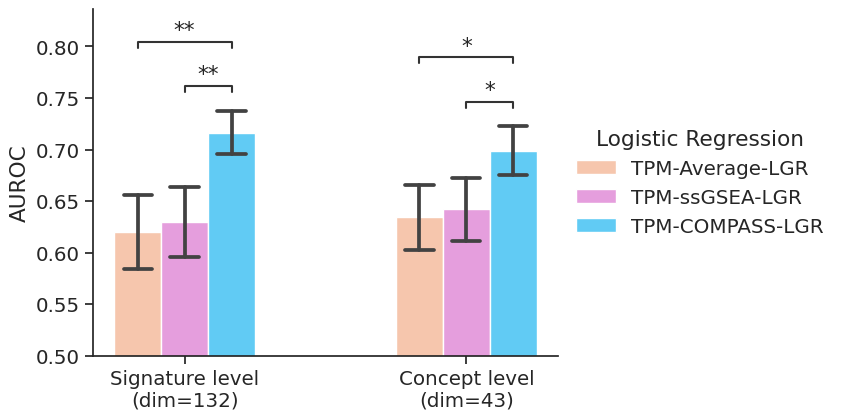

In [27]:
from statannotations.Annotator import Annotator

x='level'
y='ROC'
hue = 'mode'
labels =  ['TPM-Average-LGR',
           'TPM-ssGSEA-LGR',
          'TPM-COMPASS-LGR',      
          ]

order = ['signatures', 'concepts']
x_labelticks = ['Signature level\n(dim=132)', 'Concept level\n(dim=43)']
width = 0.5

fig, ax = plt.subplots(figsize=(6, 4.5), )
sns.barplot(data  = dfpf, x = x, errorbar = 'se', hue= hue,order = order,saturation = 1,
            hue_order = Modes, capsize=0.1, width = width, palette=palette,
            #legend=False,
            y = y, ax=ax)

ax.set_ylim(0.5, 0.8)
ax.set_ylabel('AUROC')
ax.set_xlabel('')
sns.despine()

ax.tick_params(bottom=True, left=True)


handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, labels,
           title="Logistic Regression", 
           loc='center left',        
           bbox_to_anchor=(1.0, 0.5), 
           frameon=False)

ax.set_xticklabels(x_labelticks, rotation = 0)

pairs = [
         (('concepts', 'ssGSEA from Gene TPM'),
          ('concepts','COMPASS')),
         (('concepts', 'Geometric mean from Gene TPM'),
          ('concepts','COMPASS')),

         
         (('signatures', 'ssGSEA from Gene TPM'),
          ('signatures','COMPASS')),
         (('signatures', 'Geometric mean from Gene TPM'),
          ('signatures','COMPASS')),
        ]

annot = Annotator(
    ax, pairs,
    data=dfpf, x = x, y = y, hue = hue,
    order = order, hue_order = Modes, width = width, 
    # DO NOT pass plot='barplot'
)
annot.configure(
    test='Wilcoxon',                 # or 'Mann-Whitney'
    #comparisons_correction='fdr_bh',
    text_format='star',
    show_test_name=False
)
annot.apply_and_annotate()

fig.savefig(f'./results/LGR_ROC_barplot.svg',
            bbox_inches = 'tight')

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

signatures_ssGSEA from Gene TPM vs. signatures_COMPASS: Wilcoxon test (paired samples), P_val:7.391e-02 Stat=3.300e+01
concepts_ssGSEA from Gene TPM vs. concepts_COMPASS: Wilcoxon test (paired samples), P_val:2.899e-02 Stat=2.600e+01
signatures_Geometric mean from Gene TPM vs. signatures_COMPASS: Wilcoxon test (paired samples), P_val:2.139e-02 Stat=2.400e+01
concepts_Geometric mean from Gene TPM vs. concepts_COMPASS: Wilcoxon test (paired samples), P_val:7.391e-02 Stat=3.300e+01


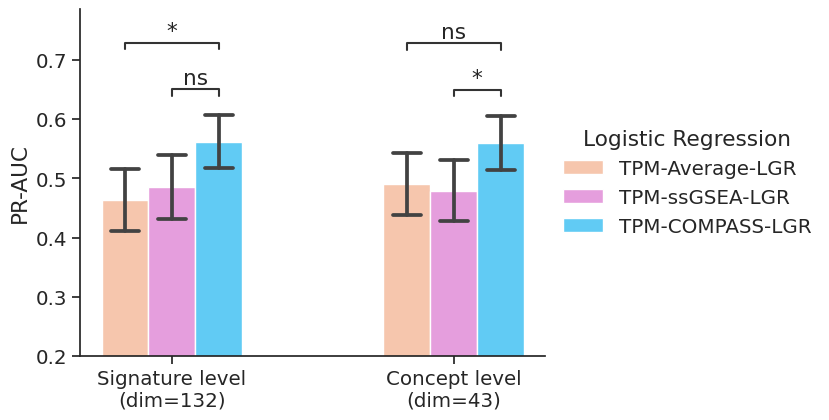

In [28]:
y='PRC'
fig, ax = plt.subplots(figsize=(6, 4.5), )
sns.barplot(data  = dfpf, x = x, errorbar = 'se', hue= hue,order = order,
            hue_order = Modes, capsize=0.1, width = width, palette=palette,saturation = 1,
            #legend=False,
            y = y, ax=ax)

ax.set_ylim(0.2, 0.75)
ax.set_ylabel('PR-AUC')
ax.set_xlabel('')
sns.despine()

ax.tick_params(bottom=True, left=True)


handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, labels,
           title="Logistic Regression", 
           loc='center left',        
           bbox_to_anchor=(1.0, 0.5), 
           frameon=False)

ax.set_xticklabels(x_labelticks, rotation = 0)


annot = Annotator(
    ax, pairs,
    data=dfpf, x = x, y = y, hue = hue,
    order = order, hue_order = Modes, width = width, 
    # DO NOT pass plot='barplot'
)
annot.configure(
    test='Wilcoxon',  
    text_format='star',
    show_test_name=True
)
annot.apply_and_annotate()


fig.savefig(f'./results/LGR_PRC_barplot.svg',
            bbox_inches = 'tight')